In [2]:
#
# Quantum Circuits for Implementing 3-Qubit Operations/Gates
#
# Alexis A. Gomez (0009-0003-0592-8553)
# alexis.gomez@utsa.edu
#
# Artyom M. Grigoryan (0000-0001-6683-0064)
# artyom.grigoryan@utsa.edu
#
# University of Texas at San Antonio
# Electrical and Computer Engineering Department
#
# March 17, 2025
#
# Paper must be reference when using this code.
# Grigoryan, A.M.; Gomez, A.; Espinoza, I.; Agaian, S.S. Signal-Induced Heap Transform-Based QR-Decomposition and Quantum Circuit for Implementing 3-Qubit Operations. Information 2025, 16, 466. https://doi.org/10.3390/info16060466
# 

from qiskit import QuantumCircuit
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import RYGate

import numpy as np
from helper_functions import GetTheoreticalProb, GetTheoreticalSV, runSampler, GetMRSE, printErrors

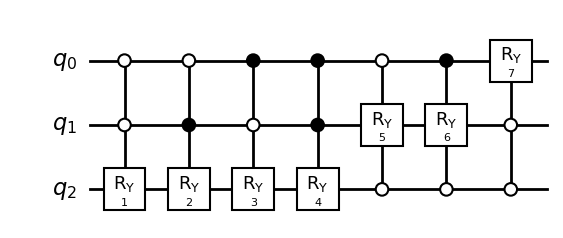

In [3]:
from qsiht_library import generalFastPath
def stage0(theta=None):
    
    if theta is None:
        theta = [1,2,3,4,5,6,7]
    else:
        theta = np.array(theta)*-2

    # Create Quantum Circuit
    qc_stage0 = QuantumCircuit(3)
    
    r1 = RYGate(theta[0])
    r2 = RYGate(theta[1])
    r3 = RYGate(theta[2])
    r4 = RYGate(theta[3])
    r5 = RYGate(theta[4])
    r6 = RYGate(theta[5])
    r7 = RYGate(theta[6])
    
    qc_stage0.append(r1.control(2, ctrl_state='00'), [2,1,0])
    qc_stage0.append(r2.control(2, ctrl_state='10'), [2,1,0])
    qc_stage0.append(r3.control(2, ctrl_state='01'), [2,1,0])
    qc_stage0.append(r4.control(2, ctrl_state='11'), [2,1,0])
    qc_stage0.append(r5.control(2, ctrl_state='00'), [2,0,1])
    qc_stage0.append(r6.control(2, ctrl_state='01'), [2,0,1])
    qc_stage0.append(r7.control(2, ctrl_state='00'), [0,1,2])
    
    return qc_stage0

stage0().reverse_bits().draw("mpl", style="bw")

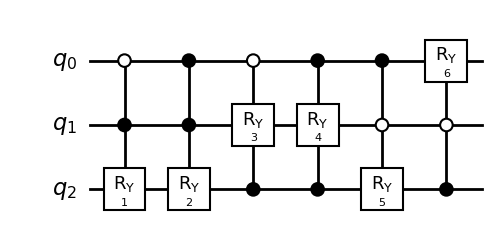

In [26]:
def stage1(theta=None):
    # Stage 1
    
    if theta is None:
        theta = [1,2,3,4,5,6]
    else:
        theta = np.array(theta)*-2
    
    # Create Quantum Circuit
    qc_stage1 = QuantumCircuit(3)
    
    r1 = RYGate(theta[0])
    r2 = RYGate(theta[1])
    r3 = RYGate(theta[2])
    r4 = RYGate(theta[3])
    r5 = RYGate(theta[4])
    r6 = RYGate(theta[5])
    
    qc_stage1.append(r1.control(2, ctrl_state='10'), [2,1,0])
    qc_stage1.append(r2.control(2, ctrl_state='11'), [2,1,0])
    qc_stage1.append(r3.control(2, ctrl_state='10'), [2,0,1])
    qc_stage1.append(r4.control(2, ctrl_state='11'), [2,0,1])
    qc_stage1.append(r5.control(2, ctrl_state='01'), [2,1,0])
    qc_stage1.append(r6.control(2, ctrl_state='01'), [0,1,2])
    
    return qc_stage1

stage1().reverse_bits().draw("mpl", style="bw")

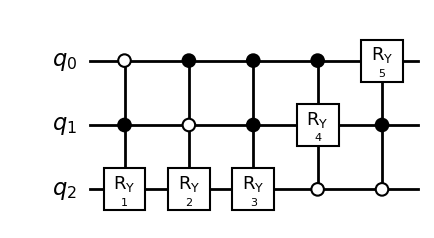

In [27]:
def stage2(theta=None):
    # Stage 1
    
    if theta is None:
        theta = [1,2,3,4,5]
    else:
        theta = np.array(theta)*-2
    
    # Create Quantum Circuit
    qc_stage2 = QuantumCircuit(3)
    
    r1 = RYGate(theta[0])
    r2 = RYGate(theta[1])
    r3 = RYGate(theta[2])
    r4 = RYGate(theta[3])
    r5 = RYGate(theta[4])
    
    qc_stage2.append(r1.control(2, ctrl_state='10'), [2,1,0])
    qc_stage2.append(r2.control(2, ctrl_state='01'), [2,1,0])
    qc_stage2.append(r3.control(2, ctrl_state='11'), [2,1,0])
    qc_stage2.append(r4.control(2, ctrl_state='01'), [2,0,1])
    qc_stage2.append(r5.control(2, ctrl_state='10'), [0,1,2])
    
    return qc_stage2

stage2().reverse_bits().draw("mpl", style="bw")

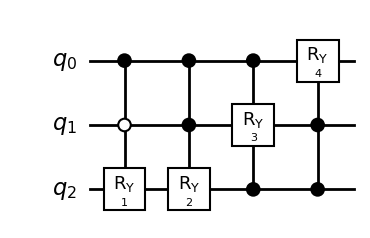

In [28]:
def stage3(theta=None):
    # Stage 1
    
    if theta is None:
        theta = [1,2,3,4]
    else:
        theta = np.array(theta)*-2
    
    # Create Quantum Circuit
    qc_stage3 = QuantumCircuit(3)
    
    r1 = RYGate(theta[0])
    r2 = RYGate(theta[1])
    r3 = RYGate(theta[2])
    r4 = RYGate(theta[3])
    
    qc_stage3.append(r1.control(2, ctrl_state='01'), [2,1,0])
    qc_stage3.append(r2.control(2, ctrl_state='11'), [2,1,0])
    qc_stage3.append(r3.control(2, ctrl_state='11'), [2,0,1])
    qc_stage3.append(r4.control(2, ctrl_state='11'), [0,1,2])
    
    return qc_stage3

stage3().reverse_bits().draw("mpl", style="bw")

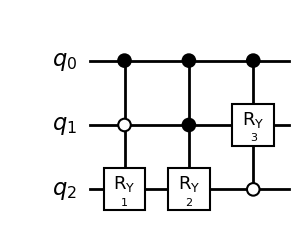

In [29]:
def stage4(theta=None):
    # Stage 1
    
    if theta is None:
        theta = [1,2,3]
    else:
        theta = np.array(theta)*-2
    
    # Create Quantum Circuit
    qc_stage4 = QuantumCircuit(3)
    
    r1 = RYGate(theta[0])
    r2 = RYGate(theta[1])
    r3 = RYGate(theta[2])
    
    qc_stage4.append(r1.control(2, ctrl_state='01'), [2,1,0])
    qc_stage4.append(r2.control(2, ctrl_state='11'), [2,1,0])
    qc_stage4.append(r3.control(2, ctrl_state='01'), [2,0,1])
    
    return qc_stage4

stage4().reverse_bits().draw("mpl", style="bw")

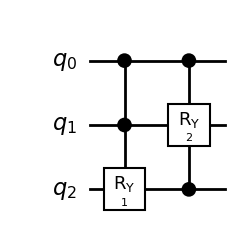

In [30]:
def stage5(theta=None):
    # Stage 1
    
    if theta is None:
        theta = [1,2]
    else:
        theta = np.array(theta)*-2
    
    # Create Quantum Circuit
    qc_stage5 = QuantumCircuit(3)
    
    r1 = RYGate(theta[0])
    r2 = RYGate(theta[1])
    
    qc_stage5.append(r1.control(2, ctrl_state='11'), [2,1,0])
    qc_stage5.append(r2.control(2, ctrl_state='11'), [2,0,1])
    
    return qc_stage5

stage5().reverse_bits().draw("mpl", style="bw")

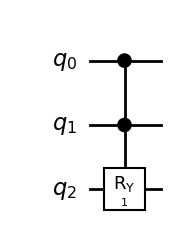

In [31]:
def stage6(theta=None):
    # Stage 1
    
    if theta is None:
        theta = [1]
    else:
        theta = np.array(theta)*-2
    
    # Create Quantum Circuit
    qc_stage6 = QuantumCircuit(3)
    
    r1 = RYGate(theta[0])
    
    qc_stage6.append(r1.control(2, ctrl_state='11'), [2,1,0])
    
    return qc_stage6

stage6().reverse_bits().draw("mpl", style="bw")

In [32]:
def threeQubitGeneralQHT(angles_arg=None, include_R=False):
    
    if angles_arg is None:
        angles_arg = {
        0: [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0],
        1: [3.5, 4.0, 4.5, 5.0, 5.5, 6.0],
        2: [6.5, 7.0, 7.5, 8.0, 8.5],
        3: [9.0, 9.5, 10.0, 10.5],
        4: [11.0, 11.5, 12.0],
        5: [12.5, 13.0],
        6: [13.5]
        }

    # Create Quantum Circuit 
    qc = QuantumCircuit(3,0)
    
    # Stage 0
    qc.append(stage0(angles_arg[0]),[0,1,2])
    
    # Stage 1
    qc.append(stage1(angles_arg[1]),[0,1,2])
    
    # Stage 2
    qc.append(stage2(angles_arg[2]),[0,1,2])
    
    # Stage 3
    qc.append(stage3(angles_arg[3]),[0,1,2])
    
    # Stage 4
    qc.append(stage4(angles_arg[4]),[0,1,2])

    # Stage 5
    qc.append(stage5(angles_arg[5]),[0,1,2])

    # Stage 6
    qc.append(stage6(angles_arg[6]),[0,1,2])
    
    qc = qc.decompose()
    
    if include_R:
        qc.ccz(2, 1, 0)

    # Display Circuit
    # display(qc.reverse_bits().draw("mpl"))
    
    return qc

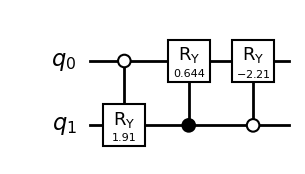

Theoretical Amplitudes: [ 2.5820e-01 5.1640e-01 7.7460e-01 2.5820e-01 ]
Amplitudes for various shots:
['2.6458e-01', '5.4772e-01', '7.4162e-01', '2.8284e-01']
['2.5100e-01', '5.1575e-01', '7.8294e-01', '2.4083e-01']
['2.6401e-01', '5.1875e-01', '7.7233e-01', '2.5436e-01']
['2.5971e-01', '5.1754e-01', '7.7340e-01', '2.5797e-01']
['2.5803e-01', '5.1678e-01', '7.7466e-01', '2.5741e-01']
['2.5824e-01', '5.1623e-01', '7.7466e-01', '2.5829e-01']
MRSE for 100 Shots: 1.3030e-02
MRSE for 1000 Shots: 5.1451e-03
MRSE for 10000 Shots: 1.9220e-03
MRSE for 100000 Shots: 5.6329e-04
MRSE for 1000000 Shots: 2.2264e-04
MRSE for 10000000 Shots: 5.1230e-05
Theoretical Probabilities: [ 6.6667e-02 2.6667e-01 6.0000e-01 6.6667e-02 ]
Probabilities for various shots:
['7.0000e-02', '3.0000e-01', '5.5000e-01', '8.0000e-02']
['6.3000e-02', '2.6600e-01', '6.1300e-01', '5.8000e-02']
['6.9700e-02', '2.6910e-01', '5.9650e-01', '6.4700e-02']
['6.7450e-02', '2.6785e-01', '5.9815e-01', '6.6550e-02']
['6.6580e-02', '2.6

In [33]:
# Example 1: 2-qubit fast IQsiHT State-Preparation for [1,-2,3,1]

# Angles for [1,-2,3,1]
U = [1.10714871779409040897235172451473772525787353515625, -0.321750554396642185484012088636518456041812896728515625, -0.95531661812450929804896304631256498396396636962890625]

# Create 2-qubit Fast Patch Circuit
qc1 = generalFastPath(2, -np.array(U))

# Display the circuit
display(qc1.decompose().draw("mpl", style="bw"))

## Prepare Circuit for Simulation
# Measure all qubits
qc1.measure_all()

# Get the theoretical statevector and probabilities
qc_true_res = GetTheoreticalProb(qc1)

# List of shots to run simulations for
qc_shots = [10**2,10**3,10**4,10**5,10**6,10**7]

# Run the Simulation
qc_stats, qc_hist = runSampler(qc1, qc_shots, qc_true_res)

# Print Amplitude from Theoretical Probabilities 
print("Theoretical Amplitudes: [ ", end='')
for prob in list(GetTheoreticalSV(qc1).values()):
    prob = "{:.4e} ".format(prob)
    print(prob,end='')
print(end=']')

# Print Amplitudes from Shot Probabilities 
print("\nAmplitudes for various shots:")
for probs in qc_stats:
    probs = np.sqrt(list(probs.values()))
    sci_prob = []
    for prob in probs:
        prob = "{:.4e}".format(prob)
        sci_prob.append(prob)
    print(sci_prob)
    
# Compute the MRSE of the Simulations
GetMRSE(qc_stats, list(qc_true_res.values()), qc_shots, probabilities=False, ExportPrint=True, scientific=True)
    
print("Theoretical Probabilities: [ ", end='')
for prob in list(qc_true_res.values()):
    prob = "{:.4e} ".format(prob)
    print(prob,end='')
print(end=']')
    
print("\nProbabilities for various shots:")
for probs in qc_stats:
    probs = list(probs.values())
    sci_prob = []
    for prob in probs:
        prob = "{:.4e}".format(prob)
        sci_prob.append(prob)
    print(sci_prob)
    
# Compute the MRSE of the Simulations
GetMRSE(qc_stats, list(qc_true_res.values()), qc_shots, ExportPrint=True, scientific=True)
print()
    

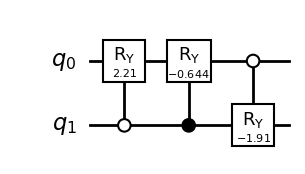

Theoretical Amplitudes: [ 2.5820e-01 8.9443e-01 3.6515e-01 0.0000e+00 ]
Amplitudes for various shots:
['2.0000e-01', '9.2736e-01', '3.1623e-01']
['2.4083e-01', '8.9610e-01', '3.7283e-01']
['2.5846e-01', '8.9381e-01', '3.6647e-01']
['2.5665e-01', '8.9417e-01', '3.6687e-01']
['2.5861e-01', '8.9427e-01', '3.6525e-01']
['2.5816e-01', '8.9452e-01', '3.6495e-01']
MRSE for 100 Shots: 2.0714e-02
MRSE for 1000 Shots: 4.7656e-03
MRSE for 10000 Shots: 3.7003e-04
MRSE for 100000 Shots: 5.8136e-04
MRSE for 1000000 Shots: 1.1358e-04
MRSE for 10000000 Shots: 5.5973e-05
Theoretical Probabilities: [ 6.6667e-02 8.0000e-01 1.3333e-01 0.0000e+00 ]
Probabilities for various shots:
['4.0000e-02', '8.6000e-01', '1.0000e-01']
['5.8000e-02', '8.0300e-01', '1.3900e-01']
['6.6800e-02', '7.9890e-01', '1.3430e-01']
['6.5870e-02', '7.9954e-01', '1.3459e-01']
['6.6879e-02', '7.9971e-01', '1.3341e-01']
['6.6647e-02', '8.0017e-01', '1.3319e-01']
MRSE for 100 Shots: 1.8409e-02
MRSE for 1000 Shots: 2.6952e-03
MRSE for 1

In [34]:
# Example 1 [Contd.]: 2-qubit fast IQsiHT State-Preparation for [1,-2,3,1]

# Angles for [1,-2,3,1]
U = [1.10714871779409040897235172451473772525787353515625, -0.321750554396642185484012088636518456041812896728515625, -0.95531661812450929804896304631256498396396636962890625]

# Create 2-qubit Fast Patch Circuit
qc2 = generalFastPath(2, -np.array(U)).inverse()

# Display the circuit
display(qc2.decompose().draw("mpl", style="bw"))

## Prepare Circuit for Simulation
# Measure all qubits
qc2.measure_all()

# Get the theoretical statevector and probabilities
qc_true_res = GetTheoreticalProb(qc2)

# Run the Simulation
qc_stats, qc_hist = runSampler(qc2, qc_shots, qc_true_res)

# Print Amplitude from Theoretical Probabilities 
print("Theoretical Amplitudes: [ ", end='')
for prob in list(GetTheoreticalSV(qc2).values()):
    prob = "{:.4e} ".format(prob)
    print(prob,end='')
print(end=']')

# Print Amplitudes from Shot Probabilities 
print("\nAmplitudes for various shots:")
for probs in qc_stats:
    probs = np.sqrt(list(probs.values()))
    sci_prob = []
    for prob in probs:
        prob = "{:.4e}".format(prob)
        sci_prob.append(prob)
    print(sci_prob)
    
# Compute the MRSE of the Simulations
GetMRSE(qc_stats, list(qc_true_res.values()), qc_shots, probabilities=False, ExportPrint=True, scientific=True)
    
print("Theoretical Probabilities: [ ", end='')
for prob in list(qc_true_res.values()):
    prob = "{:.4e} ".format(prob)
    print(prob,end='')
print(end=']')
    
print("\nProbabilities for various shots:")
for probs in qc_stats:
    probs = list(probs.values())
    sci_prob = []
    for prob in probs:
        prob = "{:.4e}".format(prob)
        sci_prob.append(prob)
    print(sci_prob)
    
# Compute the MRSE of the Simulations
GetMRSE(qc_stats, list(qc_true_res.values()), qc_shots, ExportPrint=True, scientific=True)
print()

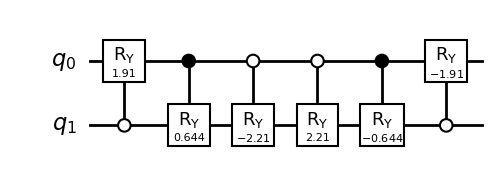

Theoretical Amplitudes: [ 1.0000e+00 6.4477e-18 2.1531e-17 8.4294e-19 ]
Amplitudes for various shots:
['1.0000e+00']
['1.0000e+00']
['1.0000e+00']
['1.0000e+00']
['1.0000e+00']
['1.0000e+00']
MRSE for 100 Shots: 5.6230e-18
MRSE for 1000 Shots: 5.6230e-18
MRSE for 10000 Shots: 5.6230e-18
MRSE for 100000 Shots: 5.6230e-18
MRSE for 1000000 Shots: 5.6230e-18
MRSE for 10000000 Shots: 5.6230e-18
Theoretical Probabilities: [ 1.0000e+00 4.1573e-35 4.6360e-34 7.1055e-37 ]
Probabilities for various shots:
['1.0000e+00']
['1.0000e+00']
['1.0000e+00']
['1.0000e+00']
['1.0000e+00']
['1.0000e+00']
MRSE for 100 Shots: 1.1637e-34
MRSE for 1000 Shots: 1.1637e-34
MRSE for 10000 Shots: 1.1637e-34
MRSE for 100000 Shots: 1.1637e-34
MRSE for 1000000 Shots: 1.1637e-34
MRSE for 10000000 Shots: 1.1637e-34



In [35]:
# Example 1 [Contd.]: 2-qubit fast IQsiHT State-Preparation for [1,2,2,1]

qc3 = QuantumCircuit(2,0)
qc3.append(qc1.remove_final_measurements(inplace=False), [0,1])
qc3.append(qc2.remove_final_measurements(inplace=False), [0,1])

# Display the circuit
display(qc3.decompose(reps=2).reverse_bits().draw("mpl", style="bw"))


## Prepare Circuit for Simulation
# Measure all qubits
qc3.measure_all()

# Get the theoretical statevector and probabilities
qc_true_res = GetTheoreticalProb(qc3)

# Run the Simulation
qc_stats, qc_hist = runSampler(qc3, qc_shots, qc_true_res)

# Print Amplitude from Theoretical Probabilities 
print("Theoretical Amplitudes: [ ", end='')
for prob in list(GetTheoreticalSV(qc3).values()):
    prob = "{:.4e} ".format(prob)
    print(prob,end='')
print(end=']')

# Print Amplitudes from Shot Probabilities 
print("\nAmplitudes for various shots:")
for probs in qc_stats:
    probs = np.sqrt(list(probs.values()))
    sci_prob = []
    for prob in probs:
        prob = "{:.4e}".format(prob)
        sci_prob.append(prob)
    print(sci_prob)
    
# Compute the MRSE of the Simulations
GetMRSE(qc_stats, list(qc_true_res.values()), qc_shots, probabilities=False, ExportPrint=True, scientific=True)
    
print("Theoretical Probabilities: [ ", end='')
for prob in list(qc_true_res.values()):
    prob = "{:.4e} ".format(prob)
    print(prob,end='')
print(end=']')
    
print("\nProbabilities for various shots:")
for probs in qc_stats:
    probs = list(probs.values())
    sci_prob = []
    for prob in probs:
        prob = "{:.4e}".format(prob)
        sci_prob.append(prob)
    print(sci_prob)
    
# Compute the MRSE of the Simulations
GetMRSE(qc_stats, list(qc_true_res.values()), qc_shots, ExportPrint=True, scientific=True)
print()

In [ ]:
# Define Different Angles for QR Decomposition

hartley_angles = {
    0: [-0.7853981633974483, -0.7853981633974483, -0.7853981633974483,
        -0.7853981633974483, -0.7853981633974483, -0.7853981633974483,
        -0.7853981633974483],
    1: [3.9269908169872414, 0.7853981633974478, -1.2858722001728342,
        4.427464853762627, -1.1633360904964964, -1.1935020131379019],
    2: [-0.2740142038101563, 2.2773497034667423, 3.415606857399949,
        0.9175327459361778, -1.024674946344577],
    3: [2.5954712731394736, 4.71238898038469, 0.9175327459361777,
        4.71238898038469],
    4: [3.926990816987241, 2.3561944901923444, -1.1780972450961724],
    5: [0.0, 4.319689898685966],
    6: [0.0]
}

qc2_angles = {
    0: [-0.9461414342286575, -0.7328019652424766, -0.665957287247576,
        -0.4714533285096928, -0.7991943762240187, -0.445620758014611,
        -0.5216234598235642],
    1: [4.174711271966112, 4.553273882771563, 4.601325442203625,
        4.09962075262986, -1.2490229732917792, -1.1658945752103467],
    2: [-0.381033635310625, 2.289021057205244, -1.1636374074702343,
        1.4228799524371827, -1.4374436720409087],
    3: [0.6045214461406977, -1.44732124346347, 1.127937056434047,
        -1.5462119798805083],
    4: [2.335886633350578, 2.7951740867756136, -0.37265178287219947],
    5: [-0.703549967530364, -0.6816704446089753],
    6: [0.47935551749140615]
}

qc4_angles = {
    0: [-0.43767455503886954, -0.36981803576101457, -0.7041629878488682, -0.32563830012087236,
        -0.6390492255666708, -0.7196830716356459, -0.7658095110622852],
    1: [-1.0329984517706698, -1.3323322433110583, 3.975020923249441, 4.509942581948964,
        4.619919678924967, 4.281570883939311],
    2: [-1.336334464193862, 1.4909259682300107, -1.320833012838987, 2.1178105579626334,
        -0.5937348477235679],
    3: [-1.4946530683503549, 0.9023813010508865, -1.5447310530902036, 0.424172076126108],
    4: [-0.3417896458414056, 1.9215813954691019, 2.0755262038538338],
    5: [-0.7720041860834073, 0.8055533750204115],
    6: [-0.6285888612179287]
}

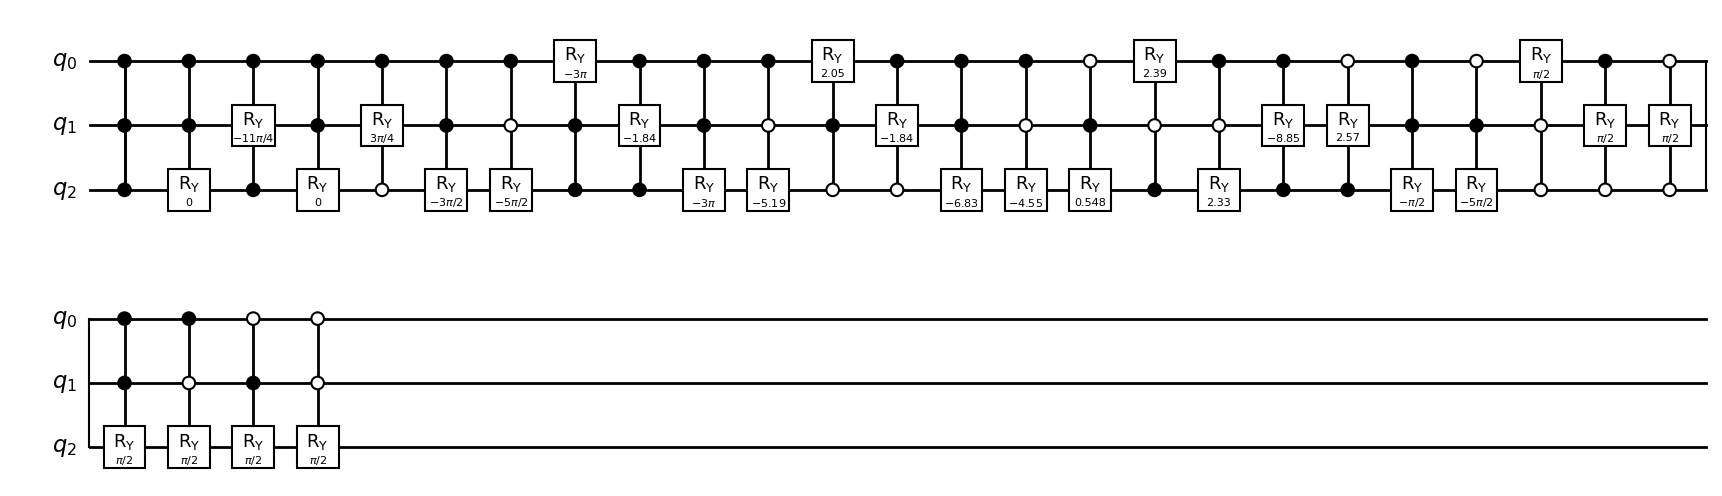

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Theoretical Amplitudes: [ 3.5355e-01 3.5355e-01 3.5355e-01 3.5355e-01 3.5355e-01 3.5355e-01 3.5355e-01 3.5355e-01 ]
Amplitudes for various shots:
['3.4641e-01', '3.4351e-01', '3.5214e-01', '3.5355e-01', '3.6469e-01', '3.4641e-01', '3.6742e-01', '3.5355e-01']
['3.5609e-01', '3.5412e-01', '3.6606e-01', '3.5721e-01', '3.4828e-01', '3.4569e-01', '3.5454e-01', '3.4598e-01']
['3.5468e-01', '3.5043e-01', '3.5437e-01', '3.5406e-01', '3.5532e-01', '3.5464e-01', '3.5027e-01', '3.5461e-01']
['3.5352e-01', '3.5355e-01', '3.5345e-01', '3.5350e-01', '3.5346e-01', '3.5405e-01', '3.5363e-01', '3.5327e-01']
MRSE for 1000 Shots: 2.8541e-03
MRSE for 10000 Shots: 2.2521e-03
MRSE for 100000 Shots: 6.6329e-04
MRSE for 1000000 Shots: 7.4246e-05
Theoretical Probabilities: [ 1.2500e-01 1.2500e-01 1.2500e-01 1.2500e-01 1.2500e-01 1.2500e-01 1.2500e-01 1.2500e-01 ]
Probabilities for various shots:
['1.2000e-01', '1.1800e-01', '1.2400e-01', '1.2500e-01', '1.3300e-01', '1.2000e-01', '1.3500e-01', '1.2500e-01']
['1

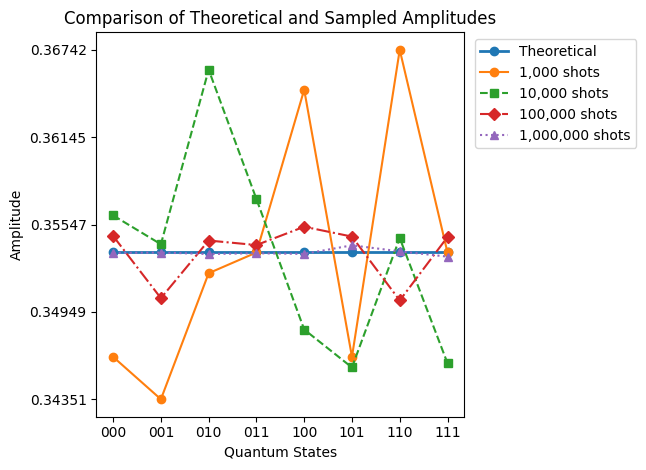

In [38]:
# Example: [QR Decomposition] Hartley Transform

for key in hartley_angles:
    hartley_angles[key] = -np.array(hartley_angles[key])

# Display Circuit
hartley_qc = threeQubitGeneralQHT(hartley_angles, include_R=True).inverse()
display(hartley_qc.reverse_bits().draw("mpl", style="bw"))

# Print Theoretical State Vector for the Hartley Transform
qct2_qc_sv = Statevector.from_instruction(hartley_qc)
display(qct2_qc_sv.draw(output="latex"))

# Get the unitary matrix
unitary = Operator(hartley_qc)
display(array_to_latex(unitary.data))

printErrors(hartley_qc)

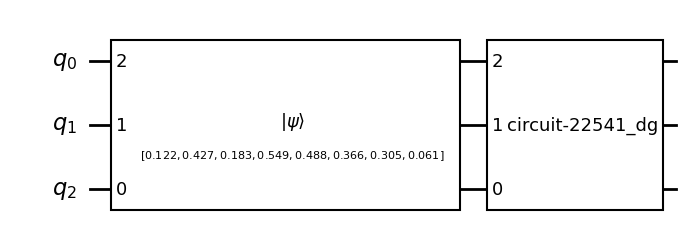

<IPython.core.display.Latex object>

Theoretical Amplitudes: [ 8.8382e-01 1.4197e-01 1.0778e-01 1.5766e-01 1.0778e-01 2.0294e-01 2.1557e-02 3.3011e-01 ]
Amplitudes for various shots:
['8.7977e-01', '1.5166e-01', '1.0488e-01', '1.7321e-01', '8.9443e-02', '1.9235e-01', '3.4205e-01']
['8.8843e-01', '1.4799e-01', '1.0817e-01', '1.5492e-01', '1.0344e-01', '1.9698e-01', '2.0000e-02', '3.2125e-01']
['8.8475e-01', '1.4075e-01', '1.0607e-01', '1.5811e-01', '1.0794e-01', '2.0408e-01', '2.3022e-02', '3.2761e-01']
['8.8390e-01', '1.4183e-01', '1.0750e-01', '1.5807e-01', '1.0690e-01', '2.0352e-01', '2.1424e-02', '3.2979e-01']
MRSE for 1000 Shots: 4.7038e-03
MRSE for 10000 Shots: 1.7699e-03
MRSE for 100000 Shots: 4.8778e-04
MRSE for 1000000 Shots: 1.5440e-04
Theoretical Probabilities: [ 7.8113e-01 2.0155e-02 1.1617e-02 2.4856e-02 1.1617e-02 4.1184e-02 4.6468e-04 1.0897e-01 ]
Probabilities for various shots:
['7.7400e-01', '2.3000e-02', '1.1000e-02', '3.0000e-02', '8.0000e-03', '3.7000e-02', '1.1700e-01']
['7.8930e-01', '2.1900e-02', '1

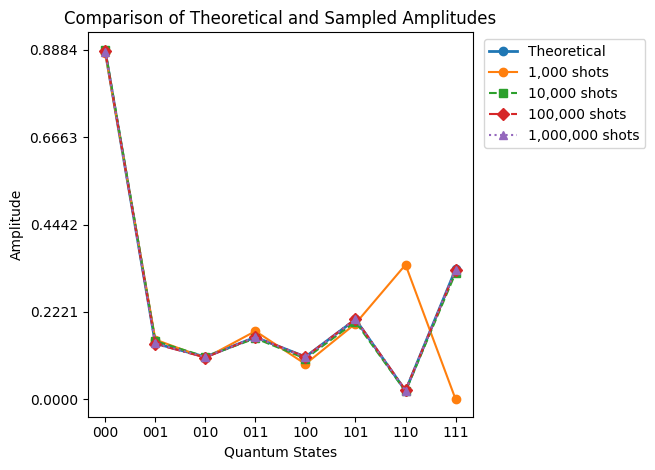

In [60]:
# Example: [QR Decomposition] Hartley Transform with Input

# Display Circuit
hartley_qc = QuantumCircuit(3)
hartley_subqc = threeQubitGeneralQHT(hartley_angles, include_R=True).inverse()
hartley_qc.initialize([2,7,3,9,8,6,5,1], [0,1,2], normalize=True)
hartley_qc.append(hartley_subqc, [0,1,2])
display(hartley_qc.reverse_bits().draw("mpl", style="bw"))

# Print Theoretical State Vector for the Hartley Transform
qct2_qc_sv = Statevector.from_instruction(hartley_qc)
display(qct2_qc_sv.draw(output="latex"))

printErrors(hartley_qc)

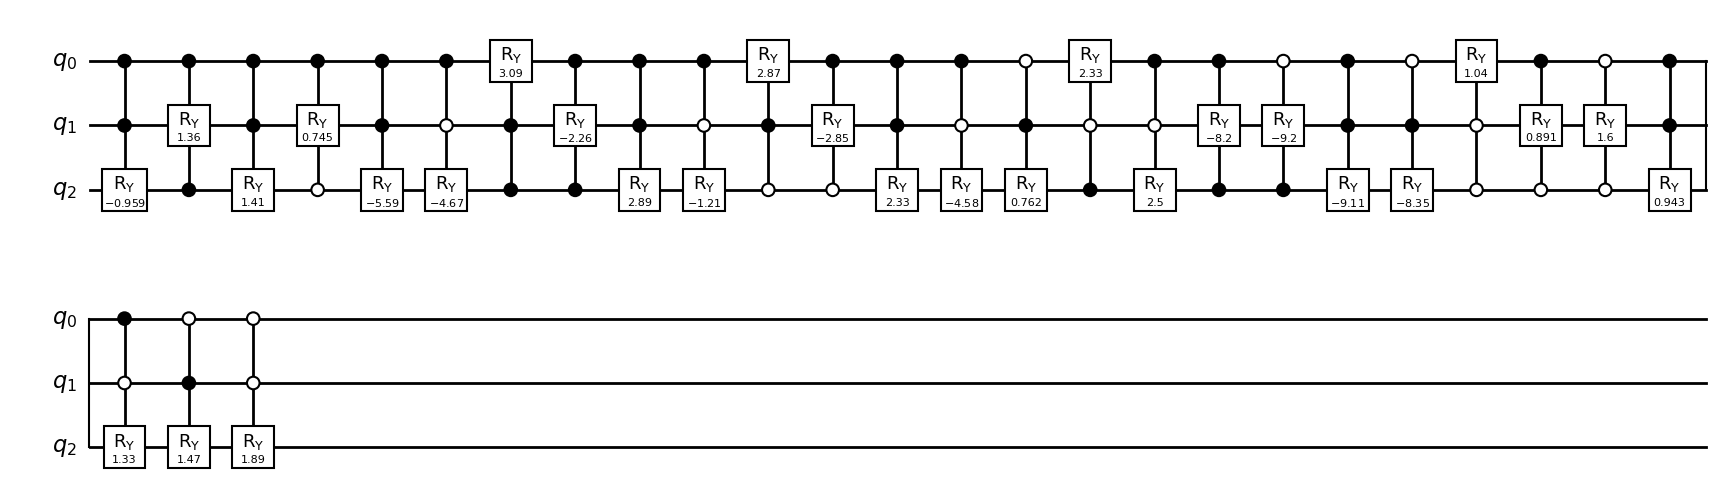

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Theoretical Amplitudes: [ 3.5355e-01 4.9039e-01 4.6194e-01 4.1573e-01 3.5355e-01 2.7779e-01 1.9134e-01 9.7545e-02 ]
Amplitudes for various shots:
['3.5637e-01', '4.7749e-01', '4.5497e-01', '4.3704e-01', '3.3466e-01', '3.0496e-01', '1.8439e-01', '8.9443e-02']
['3.6249e-01', '4.8734e-01', '4.6519e-01', '4.0915e-01', '3.5071e-01', '2.7749e-01', '1.9365e-01', '9.8995e-02']
['3.5323e-01', '4.8811e-01', '4.6373e-01', '4.1795e-01', '3.5160e-01', '2.7781e-01', '1.9155e-01', '9.8793e-02']
['3.5370e-01', '4.9026e-01', '4.6254e-01', '4.1526e-01', '3.5360e-01', '2.7764e-01', '1.9129e-01', '9.7201e-02']
MRSE for 1000 Shots: 5.4282e-03
MRSE for 10000 Shots: 1.5750e-03
MRSE for 100000 Shots: 5.4299e-04
MRSE for 1000000 Shots: 1.0985e-04
Theoretical Probabilities: [ 1.2500e-01 2.4048e-01 2.1339e-01 1.7284e-01 1.2500e-01 7.7165e-02 3.6612e-02 9.5151e-03 ]
Probabilities for various shots:
['1.2700e-01', '2.2800e-01', '2.0700e-01', '1.9100e-01', '1.1200e-01', '9.3000e-02', '3.4000e-02', '8.0000e-03']
['1

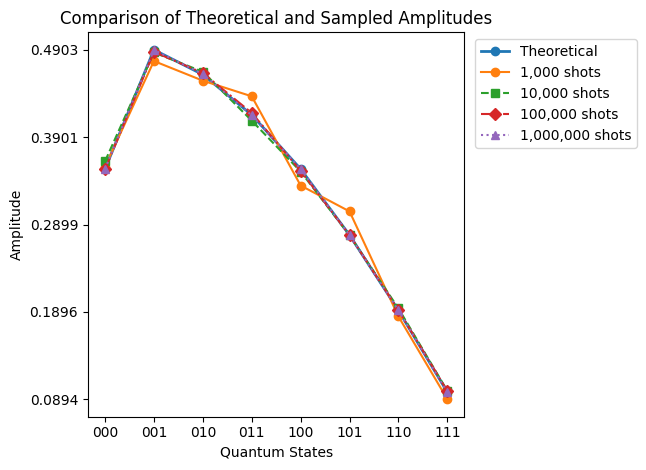

In [40]:
# Example: [QR Decomposition] DCT-II Transform

for key in qc2_angles:
    qc2_angles[key] = -np.array(qc2_angles[key])

# Display Circuit
qct2_qc = threeQubitGeneralQHT(qc2_angles).inverse()
display(qct2_qc.reverse_bits().draw("mpl", style="bw"))

# Print Theoretical State Vector for the transform
qct2_qc_sv = Statevector.from_instruction(qct2_qc)
display(qct2_qc_sv.draw(output="latex"))

# Get the unitary matrix
unitary = Operator(qct2_qc)
display(array_to_latex(unitary.data))

printErrors(qct2_qc)

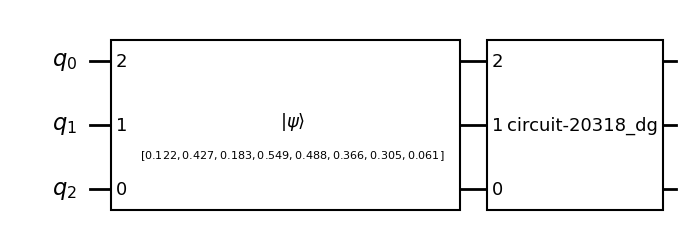

<IPython.core.display.Latex object>

Theoretical Amplitudes: [ 8.8382e-01 3.5732e-02 3.5931e-01 8.6215e-02 2.1557e-02 3.5357e-02 2.4782e-01 1.3387e-01 ]
Amplitudes for various shots:
['8.9331e-01', '3.1623e-02', '3.5071e-01', '6.3246e-02', '2.4083e-01', '1.2649e-01']
['8.8238e-01', '3.3166e-02', '3.6647e-01', '8.0623e-02', '1.4142e-02', '4.0000e-02', '2.4413e-01', '1.3454e-01']
['8.8366e-01', '3.5355e-02', '3.6061e-01', '8.9889e-02', '2.3022e-02', '3.2711e-02', '2.4613e-01', '1.3266e-01']
['8.8400e-01', '3.5972e-02', '3.5909e-01', '8.6954e-02', '2.0445e-02', '3.6180e-02', '2.4738e-01', '1.3349e-01']
MRSE for 1000 Shots: 6.2832e-03
MRSE for 10000 Shots: 1.6853e-03
MRSE for 100000 Shots: 6.7105e-04
MRSE for 1000000 Shots: 2.1421e-04
Theoretical Probabilities: [ 7.8113e-01 1.2768e-03 1.2910e-01 7.4331e-03 4.6468e-04 1.2501e-03 6.1416e-02 1.7921e-02 ]
Probabilities for various shots:
['7.9800e-01', '1.0000e-03', '1.2300e-01', '4.0000e-03', '5.8000e-02', '1.6000e-02']
['7.7860e-01', '1.1000e-03', '1.3430e-01', '6.5000e-03', '2

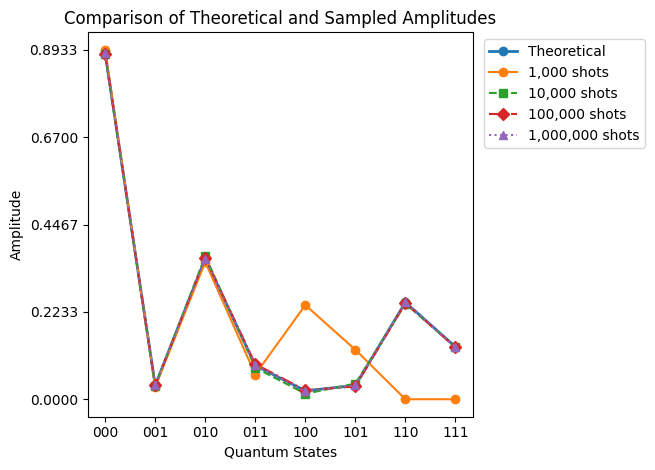

In [57]:
# Example: [QR Decomposition] DCT-II Transform with Input

# Display Circuit
qct2_qc = QuantumCircuit(3)

qct2_qc.initialize([2, 7, 3, 9, 8, 6, 5, 1], [0,1,2], normalize=True)

qct2_subqc = threeQubitGeneralQHT(qc2_angles).inverse()
qct2_qc.append(qct2_subqc, [0,1,2])

display(qct2_qc.reverse_bits().draw("mpl", style="bw"))

# Print Theoretical State Vector for the DCT-II Transform
qct2_qc_sv = Statevector.from_instruction(qct2_qc)
display(qct2_qc_sv.draw(output="latex"))

printErrors(qct2_qc)

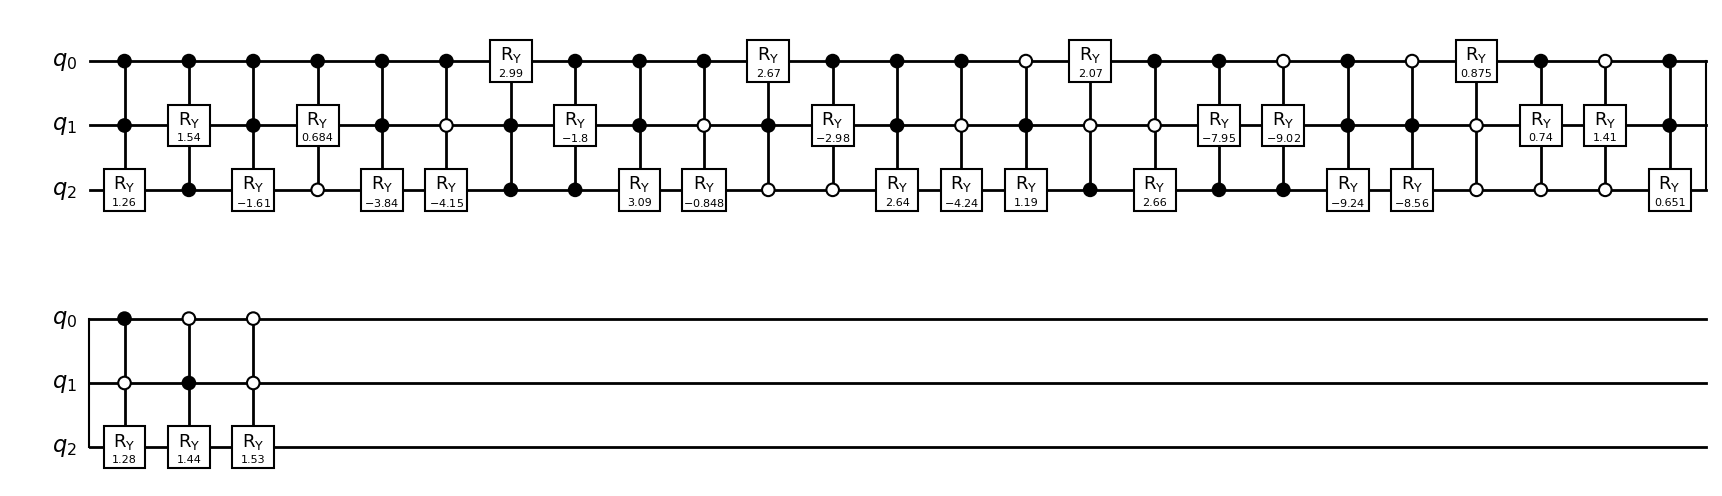

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Theoretical Amplitudes: [ 4.9759e-01 4.7847e-01 4.4096e-01 3.8651e-01 3.1720e-01 2.3570e-01 1.4514e-01 4.9009e-02 ]
Amplitudes for various shots:
['5.0100e-01', '4.7329e-01', '4.2071e-01', '4.0988e-01', '3.1145e-01', '2.3664e-01', '1.5811e-01', '4.4721e-02']
['4.9759e-01', '4.7937e-01', '4.3841e-01', '3.8497e-01', '3.2357e-01', '2.3152e-01', '1.5100e-01', '3.3166e-02']
['4.9758e-01', '4.7947e-01', '4.3992e-01', '3.8720e-01', '3.1653e-01', '2.3539e-01', '1.4509e-01', '4.9193e-02']
['4.9774e-01', '4.7925e-01', '4.4022e-01', '3.8672e-01', '3.1709e-01', '2.3561e-01', '1.4432e-01', '4.8353e-02']
MRSE for 1000 Shots: 4.3576e-03
MRSE for 10000 Shots: 2.3489e-03
MRSE for 100000 Shots: 2.2122e-04
MRSE for 1000000 Shots: 1.9133e-04
Theoretical Probabilities: [ 2.4760e-01 2.2893e-01 1.9445e-01 1.4939e-01 1.0061e-01 5.5554e-02 2.1066e-02 2.4018e-03 ]
Probabilities for various shots:
['2.5100e-01', '2.2400e-01', '1.7700e-01', '1.6800e-01', '9.7000e-02', '5.6000e-02', '2.5000e-02', '2.0000e-03']
['2

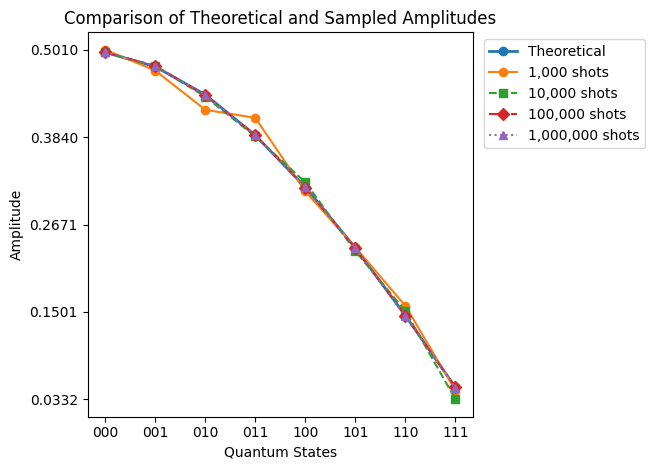

In [42]:
# Example: [QR Decomposition] DCT-IV Transform

for key in qc4_angles:
    qc4_angles[key] = -np.flip(qc4_angles[key])

# Display Circuit
qct4_qc = threeQubitGeneralQHT(qc4_angles).inverse()
display(qct4_qc.reverse_bits().draw("mpl", style="bw"))

# Print Theoretical State Vector for the transform
qct4_qc_sv = Statevector.from_instruction(qct4_qc)
display(qct4_qc_sv.draw(output="latex"))

# Get the unitary matrix
unitary = Operator(qct4_qc)
display(array_to_latex(unitary.data))

printErrors(qct4_qc)

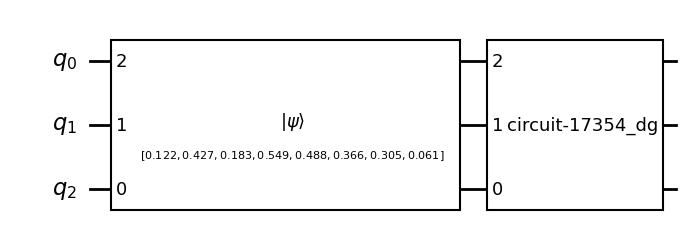

<IPython.core.display.Latex object>

Theoretical Amplitudes: [ 8.4581e-01 4.5045e-01 4.7257e-02 2.7948e-02 6.5434e-03 1.4990e-01 2.3285e-01 4.4181e-02 ]
Amplitudes for various shots:
['8.4853e-01', '4.3243e-01', '4.4721e-02', '4.4721e-02', '1.6733e-01', '2.4495e-01', '3.1623e-02']
['8.4575e-01', '4.4755e-01', '6.2450e-02', '3.1623e-02', '1.0000e-02', '1.5297e-01', '2.3302e-01', '4.1231e-02']
['8.4527e-01', '4.5047e-01', '4.7011e-02', '2.8460e-02', '7.0711e-03', '1.5136e-01', '2.3392e-01', '4.3589e-02']
['8.4621e-01', '4.4957e-01', '4.8083e-02', '2.7532e-02', '5.7446e-03', '1.5053e-01', '2.3259e-01', '4.4283e-02']
MRSE for 1000 Shots: 4.4553e-03
MRSE for 10000 Shots: 2.1023e-03
MRSE for 100000 Shots: 2.6636e-04
MRSE for 1000000 Shots: 2.1221e-04
Theoretical Probabilities: [ 7.1540e-01 2.0290e-01 2.2332e-03 7.8109e-04 4.2816e-05 2.2470e-02 5.4218e-02 1.9519e-03 ]
Probabilities for various shots:
['7.2000e-01', '1.8700e-01', '2.0000e-03', '2.0000e-03', '2.8000e-02', '6.0000e-02', '1.0000e-03']
['7.1530e-01', '2.0030e-01', '3

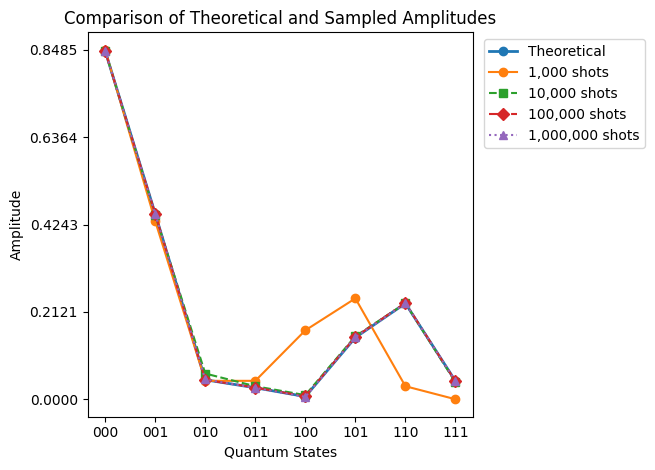

In [53]:
# Example: [QR Decomposition] DCT-IV Transform with Input

# Display Circuit
qct4_qc = QuantumCircuit(3)

qct4_qc.initialize([2, 7, 3, 9, 8, 6, 5, 1], [0,1,2], normalize=True)

qct4_subqc = threeQubitGeneralQHT(qc4_angles).inverse()
qct4_qc.append(qct4_subqc, [0,1,2])

display(qct4_qc.reverse_bits().draw("mpl", style="bw"))

# Print Theoretical State Vector for the DCT-II Transform
qct4_qc_sv = Statevector.from_instruction(qct4_qc)
display(qct4_qc_sv.draw(output="latex"))

printErrors(qct4_qc)

In [46]:
import qiskit
import qiskit_aer

# Print the Overall Qiskit version
print("Qiskit Version:", qiskit.__version__)
print("Aer Version:", qiskit_aer.__version__)

Qiskit Version: 1.3.2
Aer Version: 0.16.0
